# ACCOUNT_ID = "8edbb0bd....."    GET FROM CLOUDFLARE ACCOUNT 
# API_TOKEN = "cfut_F9WWPm6rkL9"    GET FROM CLOUDFLARE ACCOUNT FOR "WORKER AI"

<!-- save these in a .env file in same directory -->


Transcribed Prompt:  A cat is sitting on a chair.
Status: 200
Response Keys: dict_keys(['result', 'success', 'errors', 'messages'])


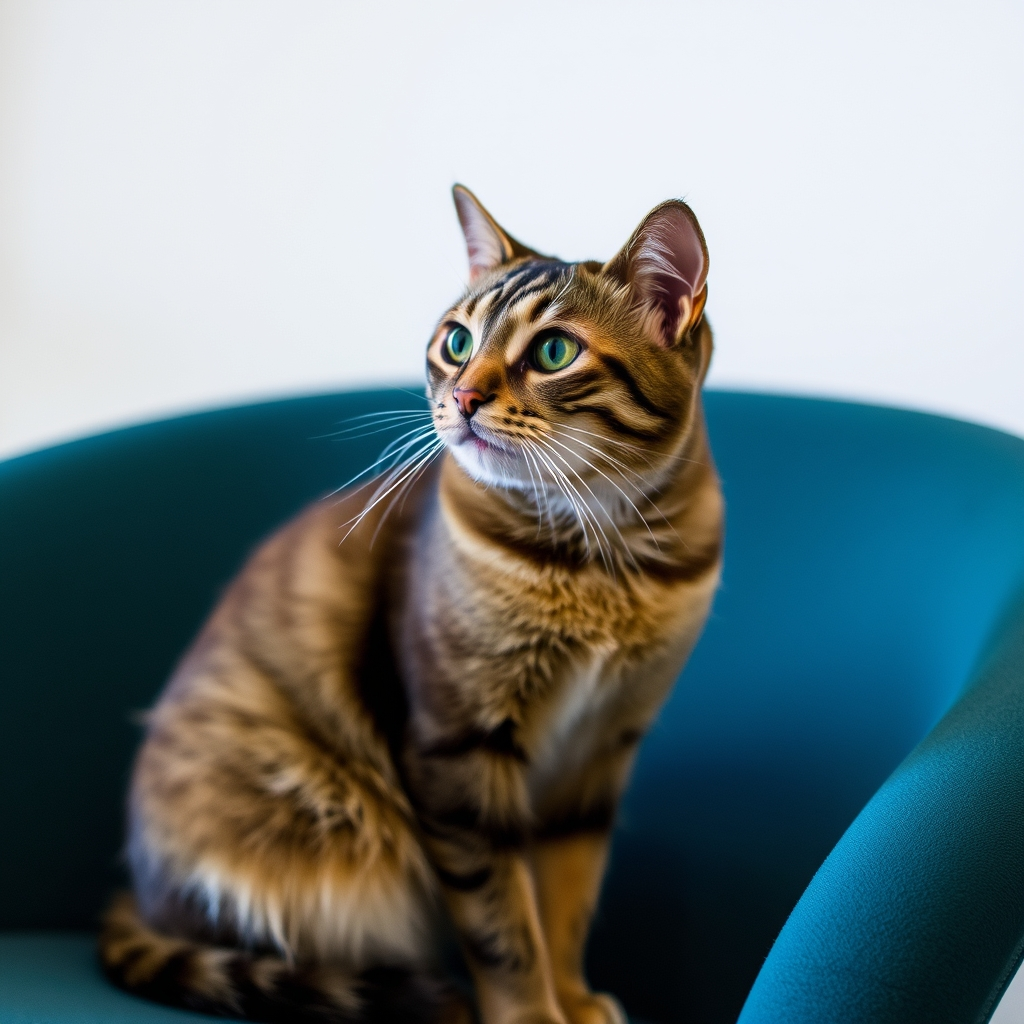

Saved as generated_image.png


In [16]:
import requests
import base64
import os
from dotenv import load_dotenv
import whisper
from io import BytesIO
from PIL import Image
from IPython.display import display

load_dotenv()
os.environ["ACCOUNT_ID"]=os.getenv("ACCOUNT_ID")
os.environ["API_TOKEN"]=os.getenv("API_TOKEN")
# =========================
# CONFIGURATION
# =========================


MODEL = "@cf/black-forest-labs/flux-1-schnell"

url = f"https://api.cloudflare.com/client/v4/accounts/{ACCOUNT_ID}/ai/run/{MODEL}"

headers = {
    "Authorization": f"Bearer {API_TOKEN}",
    "Content-Type": "application/json"
}

def transcribe_audio(file_path):
    model = whisper.load_model("small")
    result = model.transcribe(file_path,task="translate")
    return result["text"]

prompt_text = transcribe_audio("speech2.mp4")   # HERE IN PLACE OF SPPECH2.MP4 USE ANOTHER AUDIOFILE SAVED IN SAME DIRECTORY
print("Transcribed Prompt:", prompt_text)

payload = {
    "prompt":prompt_text
    # "prompt":"paharor oparere uri thoka eta ajogor"
    # "prompt": "A boy sits by a window at sunset, quietly reading as golden light fills the room."
}

# =========================
# GENERATE IMAGE
# =========================

response = requests.post(
    url,
    headers=headers,
    json=payload
)

print("Status:", response.status_code)

# If there's an error, show it
if response.status_code != 200:
    print(response.text)
    raise Exception("Cloudflare request failed")

# =========================
# DECODE BASE64 IMAGE
# =========================

data = response.json()

print("Response Keys:", data.keys())

# Cloudflare image output
image_b64 = data["result"]["image"]

image_bytes = base64.b64decode(image_b64)

# =========================
# DISPLAY IMAGE IN COLAB
# =========================

img = Image.open(BytesIO(image_bytes))

display(img)

# =========================
# SAVE IMAGE
# =========================

img.save("generated_image.png")

print("Saved as generated_image.png")

In [2]:
pip install requests

Note: you may need to restart the kernel to use updated packages.
